In [1]:
import os

In [2]:
%pwd

'/Users/pawanpahune/End to End Deep Learning Project /research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'/Users/pawanpahune/End to End Deep Learning Project '

In [ ]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epochs: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list
    params_learning_rate: float

In [6]:
from End_to_End_DL_Project.constants import *
from End_to_End_DL_Project.utils.common import read_yaml, create_directories
import tensorflow as tf

In [7]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])

        

    def get_training_config(self) -> TrainingConfig:
        training = self.config.training
        prepare_base_model = self.config.prepare_base_model
        params = self.params
        training_data = os.path.join(self.config.data_ingestion.unzip_dir, "Data")
        
        create_directories([
            Path(training.root_dir)
        ])

        training_config = TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(prepare_base_model.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE,
            params_learning_rate=params.LEARNING_RATE # <--- ADD THIS LINE
        )

        return training_config

In [8]:
import os
import urllib.request as request
from zipfile import ZipFile
import tensorflow as tf
import time
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path


In [9]:

class Training:
    def __init__(self, config: TrainingConfig):
        self.config = config
    
    def get_base_model(self):
        self.model = tf.keras.models.load_model(
            self.config.updated_base_model_path,
            compile=False 
        )
        
        # ADDED: Precision and Recall for robust medical evaluation
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.config.params_learning_rate),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy", tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
        )

    def train_valid_generator(self):
        datagenerator_kwargs = dict(
            rescale = 1./255
        )

        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear",
            class_mode="categorical" 
        )

        valid_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
            **datagenerator_kwargs
        )
        
        valid_dir = os.path.join(self.config.training_data, "valid")

        self.valid_generator = valid_datagenerator.flow_from_directory(
            directory=valid_dir,
            shuffle=False, 
            **dataflow_kwargs
        )

        if self.config.params_is_augmentation:
            train_datagenerator = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40,
                horizontal_flip=True,
                width_shift_range=0.2,
                height_shift_range=0.2,
                shear_range=0.2,
                zoom_range=0.2,
                **datagenerator_kwargs
            )
        else:
            train_datagenerator = valid_datagenerator
            
        train_dir = os.path.join(self.config.training_data, "train")

        self.train_generator = train_datagenerator.flow_from_directory(
            directory=train_dir,
            shuffle=True, 
            **dataflow_kwargs
        )
    
    @staticmethod
    def save_model(path: Path, model: tf.keras.Model):
        model.save(path)

    # --- NEW FUNCTION: Generates and saves the training graphs ---
    def save_metrics_plot(self, history):
        # Create a figure with 2 subplots (Loss and Accuracy)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Plot Training and Validation Loss
        axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
        axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red')
        axes[0].set_title('Model Loss over Epochs')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
        
        # 2. Plot Training and Validation Accuracy
        axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
        axes[1].set_title('Model Accuracy over Epochs')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True)
        
        # Save the figure to the artifacts/training directory
        plot_path = os.path.join(self.config.root_dir, "training_history_graph.png")
        plt.savefig(plot_path)
        print(f"\n--- Metrics graph saved successfully at: {plot_path} ---")
        plt.show() # Displays it inline in your Jupyter Notebook as well

    def train(self):
        self.steps_per_epoch = self.train_generator.samples // self.train_generator.batch_size
        self.validation_steps = self.valid_generator.samples // self.valid_generator.batch_size
        
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=12, 
            restore_best_weights=True,
            verbose=1
        )
        
        # Make the LR reduction more aggressive, but give it 4 epochs before triggering.
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.1, # Drop learning rate to 10% of its current value (stronger reduction)
            patience=4,
            min_lr=1e-7,
            verbose=1
        )

        # ADDED: Assign the fit function to the 'history' variable
        history = self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator,
            callbacks=[early_stopping, reduce_lr] 
        )

        # Pass the captured history to our new plotting function
        self.save_metrics_plot(history)

        self.save_model(
            path=self.config.trained_model_path,
            model=self.model
        )


[2026-06-01 03:50:49,117: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-06-01 03:50:49,120: INFO: common: yaml file: params.yaml loaded successfully]
[2026-06-01 03:50:49,121: INFO: common: created directory at: artifacts]
[2026-06-01 03:50:49,121: INFO: common: created directory at: artifacts/training]
Found 72 images belonging to 4 classes.
Found 613 images belonging to 4 classes.
Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 609ms/step - accuracy: 0.4037 - loss: 1.8739 - precision: 0.4234 - recall: 0.3702 - val_accuracy: 0.4219 - val_loss: 2.0817 - val_precision: 0.4098 - val_recall: 0.3906 - learning_rate: 1.0000e-04
Epoch 2/40
 1/38 ━━━━━━━━━━━━━━━━━━━━ 19s 524ms/step - accuracy: 0.2500 - loss: 2.0574 - precision: 0.3333 - recall: 0.2500

/Users/pawanpahune/End to End Deep Learning Project /venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2500 - loss: 2.0574 - precision: 0.3333 - recall: 0.2500 - val_accuracy: 0.3594 - val_loss: 2.2720 - val_precision: 0.3710 - val_recall: 0.3594 - learning_rate: 1.0000e-04
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 555ms/step - accuracy: 0.5561 - loss: 1.2853 - precision: 0.5787 - recall: 0.5176 - val_accuracy: 0.5781 - val_loss: 0.9305 - val_precision: 0.5789 - val_recall: 0.5156 - learning_rate: 1.0000e-04
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6875 - loss: 0.8739 - precision: 0.6923 - recall: 0.5625 - val_accuracy: 0.6250 - val_loss: 0.8668 - val_precision: 0.6481 - val_recall: 0.5469 - learning_rate: 1.0000e-04
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 562ms/step - accuracy: 0.6064 - loss: 1.0627 - precision: 0.6497 - recall: 0.5779 - val_accuracy: 0.7188 - val_loss: 0.7259 - val_precision: 0.7500 - val_recall: 0.6562 - learning_rate: 1.0000e-04
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accura

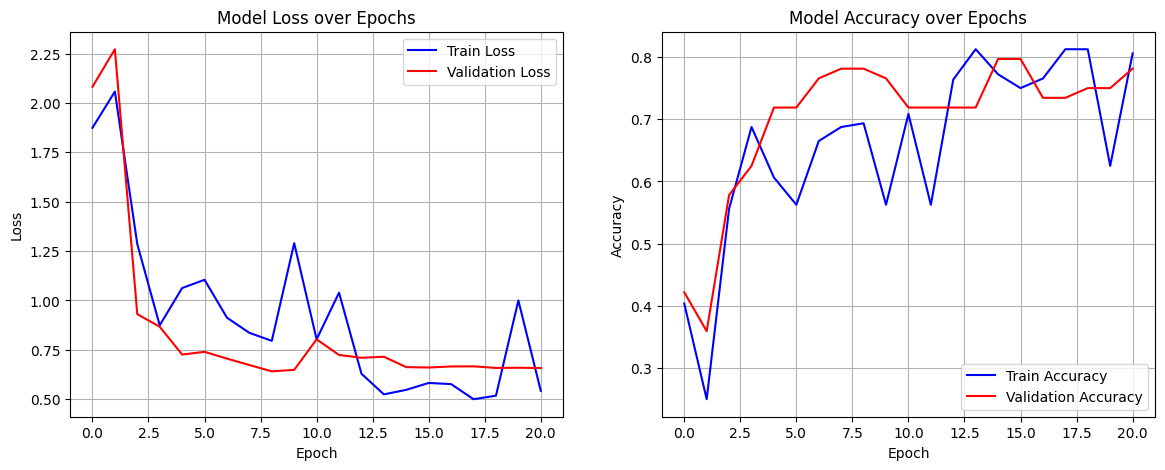

[2026-06-01 03:55:37,517: WARNING: saving_api: You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. ]


In [10]:
try:
    config = ConfigurationManager()
    training_config = config.get_training_config()
    training = Training(config=training_config)
    training.get_base_model()
    training.train_valid_generator()
    training.train()
    
except Exception as e:
    raise e